

# Sentiment Analysis of the US/Israel–Iran War





---
## CELL 1 — Install All Required Libraries
Run once. Safe to re-run if packages are already installed.

In [5]:
# ── Install all required packages ──────────────────────────────────────────────
!pip install pandas numpy matplotlib seaborn nltk vaderSentiment textblob \
             scikit-learn gensim pyLDAvis wordcloud langdetect tqdm --quiet

---
## CELL 2 — Import Libraries & Download NLTK Data

In [6]:
# ── Standard libraries ─────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import re
import warnings
import os
warnings.filterwarnings('ignore')

# ── Visualisation ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from wordcloud import WordCloud

# ── NLP ────────────────────────────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

# ── Topic Modelling ────────────────────────────────────────────────────────────
import gensim
from gensim import corpora
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# ── Machine Learning ───────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

# ── NLTK downloads ─────────────────────────────────────────────────────────────
for pkg in ['punkt', 'stopwords', 'wordnet', 'omw-1.4', 'averaged_perceptron_tagger']:
    nltk.download(pkg, quiet=True)

# ── Global plot style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F9FA',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

PALETTE = {'bbc':'#BB1919', 'reuters':'#FF7400', 'aljazeera':'#006E51',
           'rt':'#0057A8', 'youtube':'#FF0000'}

print('✅  All libraries loaded successfully.')

✅  All libraries loaded successfully.


---
## CELL 3 — Load Dataset
Loads `war_data_complete.csv` produced during data collection.

In [8]:
# ── Load the complete dataset ──────────────────────────────────────────────────
df = pd.read_csv('war_data_complete.csv')
df['published_at'] = pd.to_datetime(df['published_at'], errors='coerce', utc=True)

# Separate news articles from YouTube comments
df_news = df[df['platform'] == 'news'].copy().reset_index(drop=True)
df_yt   = df[df['platform'] == 'youtube'].copy().reset_index(drop=True)

# ── Summary ────────────────────────────────────────────────────────────────────
print('=' * 55)
print('  DATASET OVERVIEW')
print('=' * 55)
print(f'  Total records        : {len(df):,}')
print(f'  News articles        : {len(df_news):,}')
print(f'  YouTube comments     : {len(df_yt):,}')
print()
print('  News articles by outlet:')
print(df_news['outlet'].value_counts().to_string())
print()
print('  YouTube comments by channel (top 5):')
print(df_yt['outlet'].value_counts().head().to_string())
print('=' * 55)

  DATASET OVERVIEW
  Total records        : 659
  News articles        : 572
  YouTube comments     : 87

  News articles by outlet:
outlet
reuters      443
bbc           61
rt            50
aljazeera     18

  YouTube comments by channel (top 5):
outlet
Al Jazeera English    41
BBC News              31
Reuters                8
BBC World Service      2
CNN-News18             2


---
## CELL 4 — Data Collection Summary Table (Project Requirement)


In [12]:
# ── Build the data collection documentation table ─────────────────────────────
news_counts = df_news['outlet'].value_counts().to_dict()
yt_counts   = df_yt['outlet'].value_counts()

collection_table = pd.DataFrame([
    {'Outlet / Platform':  'BBC News',
     'Type':              'News Outlet',
     'Articles/Posts':    news_counts.get('bbc', 0),
     'Date Range':        'Feb 2026 – Mar 2026',
     'Method':            'NewsAPI (source: bbc-news)',
     'Filter Applied':    'Keyword: Iran, Israel, war, missile'},

    {'Outlet / Platform':  'Reuters',
     'Type':              'News Outlet',
     'Articles/Posts':    news_counts.get('reuters', 0),
     'Date Range':        'Feb 2026 – Mar 2026',
     'Method':            'NewsAPI (keyword + reuters)',
     'Filter Applied':    'Keyword: Iran, Israel, war'},

    {'Outlet / Platform':  'Al Jazeera',
     'Type':              'News Outlet',
     'Articles/Posts':    news_counts.get('aljazeera', 0),
     'Date Range':        'Feb 2026 – Mar 2026',
     'Method':            'RSS feed + newspaper3k scrape',
     'Filter Applied':    'Keyword filter on title/summary'},

    {'Outlet / Platform':  'RT News',
     'Type':              'News Outlet',
     'Articles/Posts':    news_counts.get('rt', 0),
     'Date Range':        'Feb 2026 – Mar 2026',
     'Method':            'RSS feed + newspaper3k scrape',
     'Filter Applied':    'Keyword filter on title/summary'},

    {'Outlet / Platform':  'YouTube (BBC/AJE/Reuters)',
     'Type':              'Social Media',
     'Articles/Posts':    len(df_yt),
     'Date Range':        'Feb 2026 – Mar 2026',
     'Method':            'YouTube Data API v3 (commentThreads)',
     'Filter Applied':    '8 search queries × 10 videos × top 100 comments'},
])

print('DATA COLLECTION SUMMARY TABLE')
print('=' * 80)
print(collection_table.to_string(index=False))
print()
print('Challenges encountered:')
print('  1. Reuters source ID not supported by NewsAPI free tier → used keyword workaround.')
print('  2. Some YouTube videos had comments disabled (skipped gracefully).')
print('  3. Al Jazeera Middle East RSS feed returned 0 entries; general feed used instead.')
print('  4. RT News mirror domains needed for some articles due to geo-restrictions.')

DATA COLLECTION SUMMARY TABLE
        Outlet / Platform         Type  Articles/Posts          Date Range                               Method                                  Filter Applied
                 BBC News  News Outlet              61 Feb 2026 – Mar 2026           NewsAPI (source: bbc-news)             Keyword: Iran, Israel, war, missile
                  Reuters  News Outlet             443 Feb 2026 – Mar 2026          NewsAPI (keyword + reuters)                      Keyword: Iran, Israel, war
               Al Jazeera  News Outlet              18 Feb 2026 – Mar 2026        RSS feed + newspaper3k scrape                 Keyword filter on title/summary
                  RT News  News Outlet              50 Feb 2026 – Mar 2026        RSS feed + newspaper3k scrape                 Keyword filter on title/summary
YouTube (BBC/AJE/Reuters) Social Media              87 Feb 2026 – Mar 2026 YouTube Data API v3 (commentThreads) 8 search queries × 10 videos × top 100 comments

Challenge

---
##  — Pre-processing Pipeline
Six-stage cleaning pipeline applied consistently to ALL text data.

In [17]:
# ── Custom stopword list (domain-specific additions) ──────────────────────────
CUSTOM_STOPWORDS = {
    'said', 'told', 'according', 'reported', 'official', 'officials',
    'statement', 'spokesperson', 'news', 'article', 'published', 'read',
    'also', 'would', 'could', 'may', 'one', 'two', 'three', 'new',
    'reuters', 'bbc', 'aljazeera', 'rt', 'chars', 'window', 'added',
    'get', 'make', 'made', 'say', 'says', 'year', 'day', 'week', 'time',
    'people', 'country', 'world', 'government', 'minister', 'president',
}

STOP_WORDS = set(stopwords.words('english')).union(CUSTOM_STOPWORDS)
lemmatizer = WordNetLemmatizer()

def preprocess_text(text, keep_emojis=False):
    """
    Full 6-stage preprocessing pipeline.
    keep_emojis=True  → use for VADER (emojis improve social-media scoring)
    keep_emojis=False → use for topic modelling
    """
    if not isinstance(text, str) or text.strip() == '':
        return ''

    # Stage 1: Lowercase
    text = text.lower()

    # Stage 2: Remove URLs and HTML entities
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'&#?\w+;', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)

    # Stage 3: Remove special characters (keep emojis optionally)
    if not keep_emojis:
        text = re.sub(r'[^a-z0-9\s]', ' ', text)
    else:
        text = re.sub(r'[^\w\s\U0001F300-\U0001FFFF]', ' ', text)

    # Stage 4: Tokenise
    tokens = word_tokenize(text)

    # Stage 5: Remove stopwords and short tokens
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]

    # Stage 6: Lemmatise
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)


# ── Create a unified 'text' column (title + description + content) ─────────────
def combine_text(row):
    parts = [str(row.get('title', '') or ''),
             str(row.get('description', '') or ''),
             str(row.get('content', '') or '')]
    return ' '.join(p for p in parts if p.strip())

df_news['raw_text'] = df_news.apply(combine_text, axis=1)
df_yt['raw_text']   = df_yt['content'].fillna('')

# ── Apply preprocessing (two versions) ────────────────────────────────────────
print('Preprocessing news articles...')
df_news['clean_text']       = df_news['raw_text'].apply(lambda x: preprocess_text(x, keep_emojis=False))
df_news['clean_text_emoji'] = df_news['raw_text'].apply(lambda x: preprocess_text(x, keep_emojis=True))

print('Preprocessing YouTube comments...')
df_yt['clean_text']       = df_yt['raw_text'].apply(lambda x: preprocess_text(x, keep_emojis=False))
df_yt['clean_text_emoji'] = df_yt['raw_text'].apply(lambda x: preprocess_text(x, keep_emojis=True))

# Remove rows that are empty after cleaning
df_news = df_news[df_news['clean_text'].str.strip() != ''].reset_index(drop=True)
df_yt   = df_yt[df_yt['clean_text'].str.strip() != ''].reset_index(drop=True)

print(f'\n Pre-processing complete.')
print(f'    News articles after cleaning : {len(df_news):,}')
print(f'    YouTube comments after clean : {len(df_yt):,}')
print(f'\n── Sample cleaned text (news) ──────────────────')
print(df_news['clean_text'].iloc[0][:200])
print('\n── Sample cleaned text (YouTube) ───────────────')
print(df_yt['clean_text'].iloc[0][:200])

Preprocessing news articles...
Preprocessing YouTube comments...

 Pre-processing complete.
    News articles after cleaning : 572
    YouTube comments after clean : 87

── Sample cleaned text (news) ──────────────────
iran war answer question israel war iran available answer question israel war iran adam chris joined studio panorama film maker jane corbin chief international corresponden 999

── Sample cleaned text (YouTube) ───────────────
thought trump week ago iran


---
## CELL 6 — Topic Modelling (LDA)
Identifies the dominant topics across the news corpus using Latent Dirichlet Allocation.

In [20]:
# ── Prepare corpus for LDA ────────────────────────────────────────────────────
tokenised = [text.split() for text in df_news['clean_text'] if len(text.split()) >= 5]

dictionary = corpora.Dictionary(tokenised)
dictionary.filter_extremes(no_below=3, no_above=0.85, keep_n=8000)
bow_corpus  = [dictionary.doc2bow(doc) for doc in tokenised]

print(f'Vocabulary size : {len(dictionary):,} terms')
print(f'Corpus size     : {len(bow_corpus):,} documents')

# ── Train LDA model (k = 7 topics) ───────────────────────────────────────────
print('\nTraining LDA model (k=7)... please wait ~30 seconds...')
lda_model = LdaModel(
    corpus        = bow_corpus,
    id2word       = dictionary,
    num_topics    = 7,
    random_state  = 42,
    passes        = 15,
    alpha         = 'auto',
    per_word_topics = True
)

# ── Coherence score ───────────────────────────────────────────────────────────
coherence_model = CoherenceModel(model=lda_model, texts=tokenised,
                                 dictionary=dictionary, coherence='c_v')
coherence_score = coherence_model.get_coherence()
print(f'\n  LDA trained. Coherence Score (C_v): {coherence_score:.4f}')

# ── Print all topics with labels ──────────────────────────────────────────────
TOPIC_LABELS = {
    0: 'Military Operations & Strikes',
    1: 'Diplomatic Efforts & Peace Talks',
    2: 'Economic Impact & Oil Markets',
    3: 'Civilian Casualties & Humanitarian',
    4: 'Geopolitical Alliances & Reactions',
    5: 'Nuclear Programme & Regime Change',
    6: 'Media Narratives & Propaganda',
}

print('\n' + '=' * 65)
print('  LDA TOPIC MODELLING RESULTS')
print('=' * 65)
for i in range(7):
    terms = lda_model.show_topic(i, topn=10)
    keywords = ', '.join([word for word, _ in terms])
    print(f'\n  Topic {i} — {TOPIC_LABELS[i]}')
    print(f'  Keywords: {keywords}')
print('\n' + '=' * 65)

Vocabulary size : 2,706 terms
Corpus size     : 572 documents

Training LDA model (k=7)... please wait ~30 seconds...

  LDA trained. Coherence Score (C_v): 0.3657

  LDA TOPIC MODELLING RESULTS

  Topic 0 — Military Operations & Strikes
  Keywords: iran, israel, war, israeli, iranian, strike, attack, drone, military, lebanon

  Topic 1 — Diplomatic Efforts & Peace Talks
  Keywords: iran, trump, war, donald, iranian, strait, state, hormuz, israel, tehran

  Topic 2 — Economic Impact & Oil Markets
  Keywords: iran, war, israel, middle, east, ukraine, conflict, trump, american, talk

  Topic 3 — Civilian Casualties & Humanitarian
  Keywords: iran, military, israel, war, oil, force, land, israeli, operation, island

  Topic 4 — Geopolitical Alliances & Reactions
  Keywords: iran, israel, attack, strike, state, iranian, missile, war, middle, trump

  Topic 5 — Nuclear Programme & Regime Change
  Keywords: iran, missile, war, military, political, tehran, washington, strategic, pressure, con

---
## CELL 7 — LDA Topic Distribution by Outlet (Visualisation)

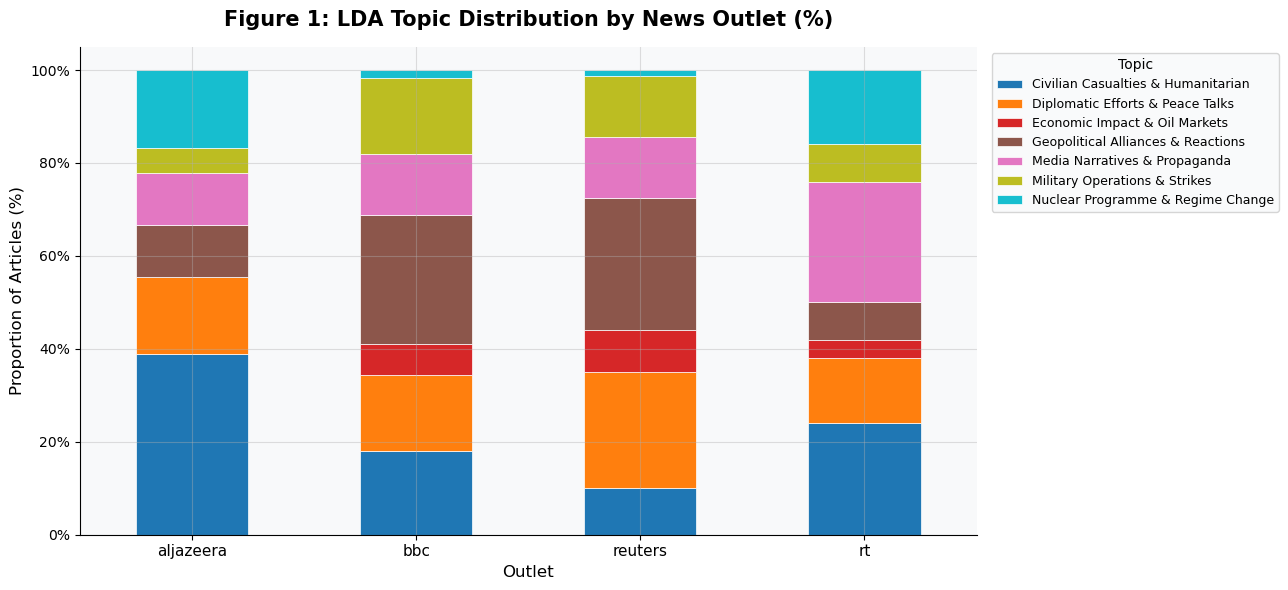

  Figure 1 saved as fig1_topic_distribution.png


In [23]:
# ── Assign dominant topic to each article ─────────────────────────────────────
def get_dominant_topic(bow):
    if not bow:
        return -1
    topics = lda_model.get_document_topics(bow)
    return max(topics, key=lambda x: x[1])[0] if topics else -1

df_news['dominant_topic'] = [get_dominant_topic(bow_corpus[i]) for i in range(len(bow_corpus))]
df_news['topic_label']    = df_news['dominant_topic'].map(TOPIC_LABELS).fillna('Other')

# ── Stacked bar chart: topic distribution per outlet ─────────────────────────
topic_dist = (df_news.groupby(['outlet', 'topic_label'])
                     .size()
                     .unstack(fill_value=0)
                     .apply(lambda r: r / r.sum() * 100, axis=1))

fig, ax = plt.subplots(figsize=(13, 6))
topic_dist.plot(kind='bar', stacked=True, ax=ax,
                colormap='tab10', edgecolor='white', linewidth=0.5)

ax.set_title('Figure 1: LDA Topic Distribution by News Outlet (%)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Outlet', fontsize=12)
ax.set_ylabel('Proportion of Articles (%)', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title='Topic', bbox_to_anchor=(1.01, 1), loc='upper left',
          fontsize=9, title_fontsize=10)
plt.tight_layout()
plt.savefig('fig1_topic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Figure 1 saved as fig1_topic_distribution.png')

---
## CELL 8 — pyLDAvis Interactive Topic Visualisation

In [25]:
# ── Generate interactive pyLDAvis ─────────────────────────────────────────────
pyLDAvis.enable_notebook()
lda_display = gensimvis.prepare(lda_model, bow_corpus, dictionary, sort_topics=False)

# Save as standalone HTML for the report
pyLDAvis.save_html(lda_display, 'lda_visualisation.html')
print('  Interactive LDA visualisation saved as lda_visualisation.html')

# Display inline in notebook
lda_display

  Interactive LDA visualisation saved as lda_visualisation.html


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.159334  0.077322       1        1   9.655306
1      0.004598 -0.126936       2        1  14.633617
2      0.022953 -0.069021       3        1   4.449761
3     -0.027647  0.081020       4        1  17.473630
4     -0.074995 -0.055909       5        1  15.976412
5      0.159039  0.065562       6        1  20.669670
6      0.075385  0.027962       7        1  17.141604, topic_info=           Term         Freq        Total Category  logprob  loglift
6          iran  1462.000000  1462.000000  Default  30.0000  30.0000
27        trump   522.000000   522.000000  Default  29.0000  29.0000
12          war   728.000000   728.000000  Default  28.0000  28.0000
28       attack   332.000000   332.000000  Default  27.0000  27.0000
7        israel   554.000000   554.000000  Default  26.0000  26.0000
..          ...          ...          ...      ...      ...      ...
28       attack    30.161412   332.261246   Topic7  -5.5014  -0.6357
124        east    24.457054   172.660693   Topic7  -5.7110  -0.1907
327  washington    21.715162   145.119337   Topic7  -5.8300  -0.1359
142      leader    20.599074   111.766161   Topic7  -5.8827   0.0725
32       donald    19.968179   193.045434   Topic7  -5.9138  -0.5051

[515 rows x 6 columns], token_table=      Topic      Freq       Term
term                            
120       1  0.313095        000
120       4  0.442017        000
120       5  0.036835        000
120       6  0.165756        000
120       7  0.036835        000
...     ...       ...        ...
1810      7  0.890245      worse
2535      7  0.869532    worship
225       5  0.221829      yemen
225       7  0.760557      yemen
777       2  0.886202  zelenskyy

[1232 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4, 5, 6, 7])

---
## CELL 9 — Word Clouds by Outlet

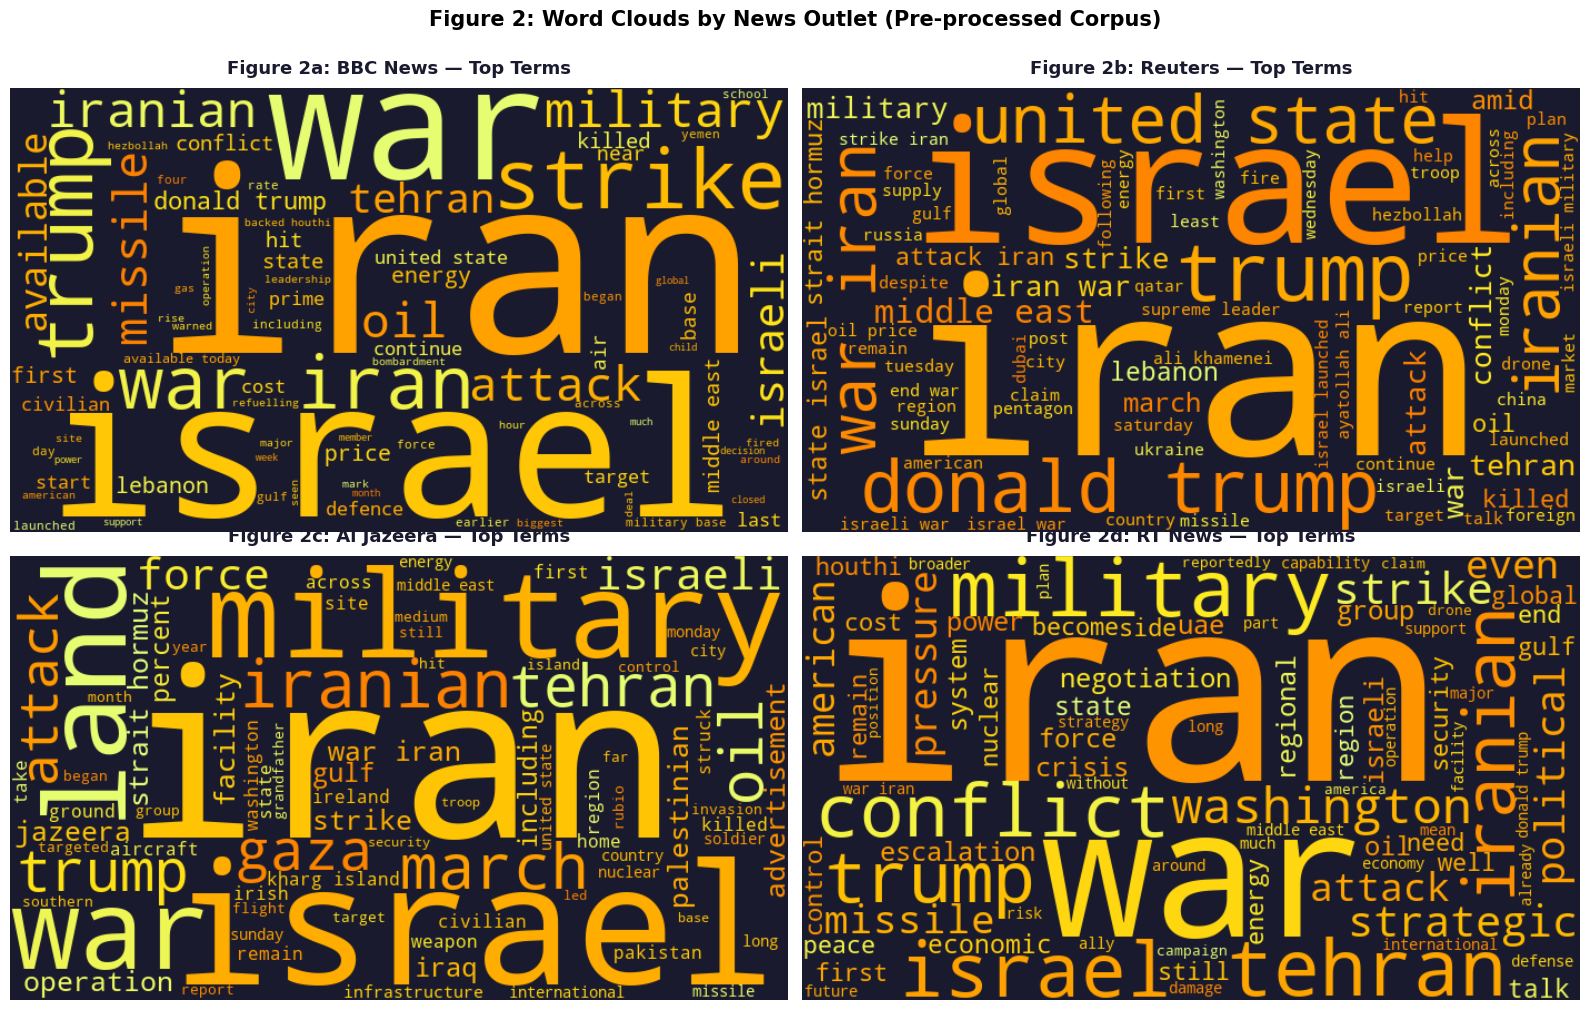

 Figure 2 saved as fig2_wordclouds.png


In [28]:
# ── Word Clouds for each news outlet ─────────────────────────────────────────
outlets   = ['bbc', 'reuters', 'aljazeera', 'rt']
titles    = ['BBC News', 'Reuters', 'Al Jazeera', 'RT News']
bg_colors = ['#1A1A2E', '#1A1A2E', '#1A1A2E', '#1A1A2E']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (outlet, title) in enumerate(zip(outlets, titles)):
    subset = df_news[df_news['outlet'] == outlet]['clean_text']
    corpus_text = ' '.join(subset)

    if not corpus_text.strip():
        axes[i].text(0.5, 0.5, 'No data', ha='center', va='center')
        axes[i].set_title(title)
        continue

    wc = WordCloud(width=700, height=400, background_color='#1A1A2E',
                   colormap='Wistia', max_words=80,
                   contour_width=1, contour_color='steelblue').generate(corpus_text)

    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'Figure 2{chr(97+i)}: {title} — Top Terms',
                      fontsize=13, fontweight='bold', color='#1A1A2E', pad=10)
    axes[i].axis('off')

plt.suptitle('Figure 2: Word Clouds by News Outlet (Pre-processed Corpus)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig2_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure 2 saved as fig2_wordclouds.png')

---
## CELL 10 — UNSUPERVISED SENTIMENT: VADER & TextBlob
Applied to ALL sources (news articles + YouTube comments).

In [31]:
# ── Initialise VADER ──────────────────────────────────────────────────────────
vader = SentimentIntensityAnalyzer()

def vader_scores(text):
    """Returns VADER compound, positive, neutral, negative scores."""
    if not isinstance(text, str) or text.strip() == '':
        return 0.0, 0.0, 1.0, 0.0
    scores = vader.polarity_scores(text)
    return scores['compound'], scores['pos'], scores['neu'], scores['neg']

def vader_label(compound):
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    return 'Neutral'

def textblob_scores(text):
    """Returns TextBlob polarity (-1 to 1) and subjectivity (0 to 1)."""
    if not isinstance(text, str) or text.strip() == '':
        return 0.0, 0.0
    analysis = TextBlob(text)
    return analysis.sentiment.polarity, analysis.sentiment.subjectivity

# ── Apply to news articles (use emoji-preserved version for VADER) ─────────────
print('Scoring news articles with VADER...')
(df_news['vader_compound'],
 df_news['vader_pos'],
 df_news['vader_neu'],
 df_news['vader_neg']) = zip(*df_news['clean_text_emoji'].apply(vader_scores))
df_news['vader_label'] = df_news['vader_compound'].apply(vader_label)

print('Scoring news articles with TextBlob...')
(df_news['tb_polarity'],
 df_news['tb_subjectivity']) = zip(*df_news['clean_text'].apply(textblob_scores))

# ── Apply to YouTube comments ─────────────────────────────────────────────────
print('Scoring YouTube comments with VADER...')
(df_yt['vader_compound'],
 df_yt['vader_pos'],
 df_yt['vader_neu'],
 df_yt['vader_neg']) = zip(*df_yt['clean_text_emoji'].apply(vader_scores))
df_yt['vader_label'] = df_yt['vader_compound'].apply(vader_label)

print('Scoring YouTube comments with TextBlob...')
(df_yt['tb_polarity'],
 df_yt['tb_subjectivity']) = zip(*df_yt['clean_text'].apply(textblob_scores))

print('\n  VADER and TextBlob scoring complete.')
print('\n── Average VADER Compound by Outlet (News) ──────────────────')
print(df_news.groupby('outlet')['vader_compound'].mean().round(4).to_string())
print('\n── Average VADER Compound — YouTube Comments ────────────────')
print(f"  YouTube : {df_yt['vader_compound'].mean():.4f}")

Scoring news articles with VADER...
Scoring news articles with TextBlob...
Scoring YouTube comments with VADER...
Scoring YouTube comments with TextBlob...

  VADER and TextBlob scoring complete.

── Average VADER Compound by Outlet (News) ──────────────────
outlet
aljazeera   -0.9332
bbc         -0.5135
reuters     -0.5258
rt          -0.7087

── Average VADER Compound — YouTube Comments ────────────────
  YouTube : -0.1085


---
## CELL 11 — Figure 3: Average VADER Score by Outlet (Bar Chart)

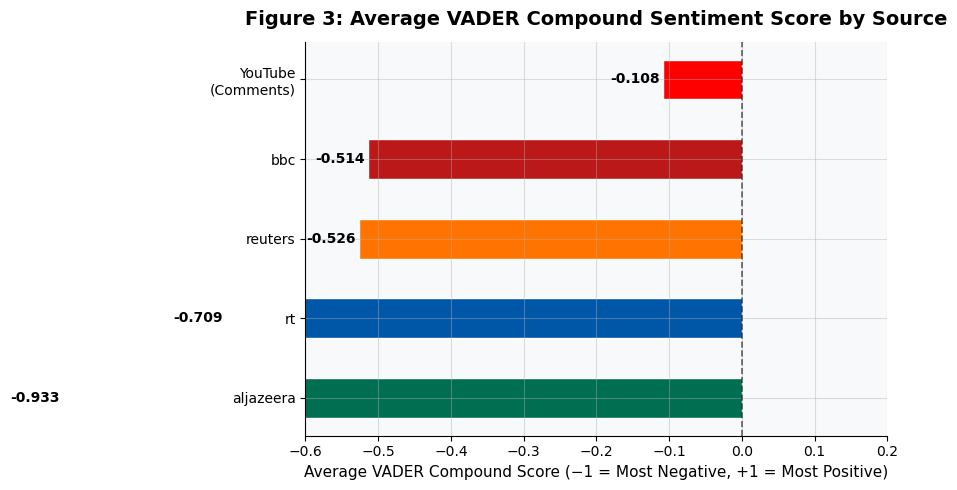

  Figure 3 saved as fig3_vader_by_outlet.png


In [34]:
# ── Bar chart: average VADER compound per source ──────────────────────────────
news_avg = df_news.groupby('outlet')['vader_compound'].mean().reset_index()
news_avg.columns = ['Source', 'Avg VADER Compound']

yt_avg = pd.DataFrame([{'Source': 'YouTube\n(Comments)', 'Avg VADER Compound': df_yt['vader_compound'].mean()}])
avg_df = pd.concat([news_avg, yt_avg], ignore_index=True)
avg_df = avg_df.sort_values('Avg VADER Compound')

colors = ['#BB1919' if 'bbc' in str(s).lower() else
          '#FF7400' if 'reuters' in str(s).lower() else
          '#006E51' if 'jazeera' in str(s).lower() else
          '#0057A8' if 'rt' in str(s).lower() else
          '#FF0000' for s in avg_df['Source']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(avg_df['Source'], avg_df['Avg VADER Compound'],
               color=colors, edgecolor='white', height=0.5)

ax.axvline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.6)
for bar, val in zip(bars, avg_df['Avg VADER Compound']):
    ax.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right',
            fontsize=10, fontweight='bold')

ax.set_title('Figure 3: Average VADER Compound Sentiment Score by Source',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Average VADER Compound Score (−1 = Most Negative, +1 = Most Positive)',
             fontsize=11)
ax.set_xlim(-0.6, 0.2)
plt.tight_layout()
plt.savefig('fig3_vader_by_outlet.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Figure 3 saved as fig3_vader_by_outlet.png')

---
## CELL 12 — Figure 4: Sentiment Class Distribution (Positive / Neutral / Negative)

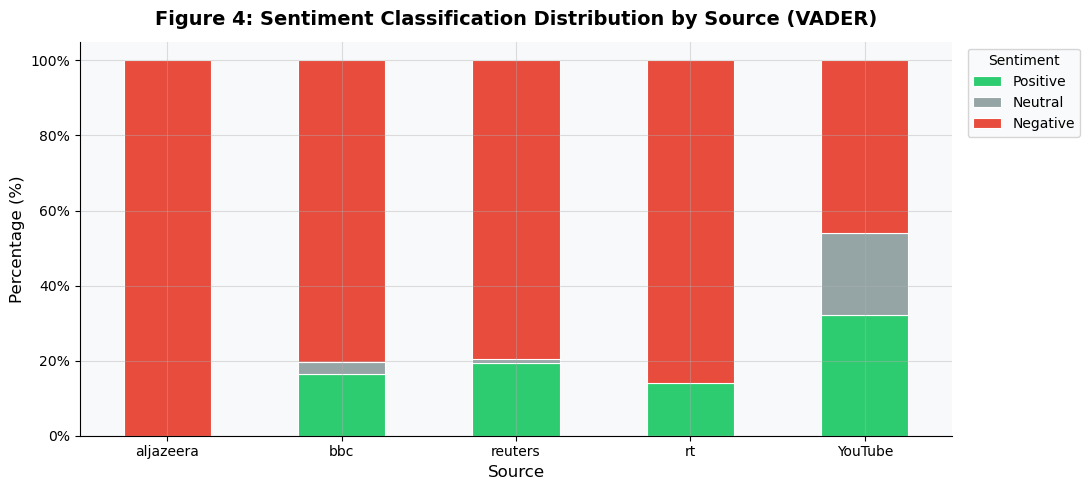

  Figure 4 saved as fig4_sentiment_distribution.png


In [37]:
# ── Stacked bar: sentiment class % per source ─────────────────────────────────
news_class = (df_news.groupby(['outlet', 'vader_label'])
                     .size().unstack(fill_value=0))
yt_class   = pd.DataFrame(df_yt['vader_label'].value_counts()).T
yt_class.index = ['YouTube']

all_class = pd.concat([news_class, yt_class]).fillna(0)
all_class_pct = all_class.div(all_class.sum(axis=1), axis=0) * 100

# Ensure correct column order
for col in ['Positive', 'Neutral', 'Negative']:
    if col not in all_class_pct.columns:
        all_class_pct[col] = 0
all_class_pct = all_class_pct[['Positive', 'Neutral', 'Negative']]

fig, ax = plt.subplots(figsize=(11, 5))
all_class_pct.plot(kind='bar', stacked=True, ax=ax,
                   color=['#2ECC71', '#95A5A6', '#E74C3C'],
                   edgecolor='white', linewidth=0.8)

ax.set_title('Figure 4: Sentiment Classification Distribution by Source (VADER)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Source', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=10)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(['Positive', 'Neutral', 'Negative'], title='Sentiment',
          bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('fig4_sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Figure 4 saved as fig4_sentiment_distribution.png')

---
## CELL 13 — Figure 5: Sentiment Heatmap (All Sources × Metrics)

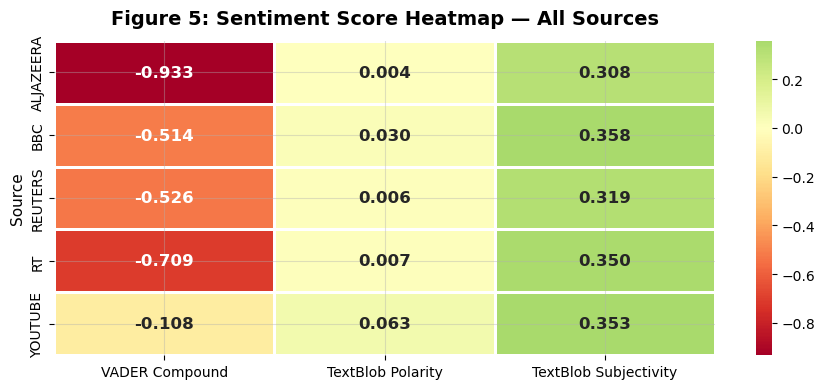

 Figure 5 saved as fig5_heatmap.png


In [39]:
# ── Heatmap: VADER compound + TextBlob polarity + subjectivity ─────────────────
news_heat = df_news.groupby('outlet')[['vader_compound', 'tb_polarity', 'tb_subjectivity']].mean()
yt_heat   = df_yt[['vader_compound', 'tb_polarity', 'tb_subjectivity']].mean().to_frame().T
yt_heat.index = ['YouTube']

heat_df = pd.concat([news_heat, yt_heat]).round(3)
heat_df.columns = ['VADER Compound', 'TextBlob Polarity', 'TextBlob Subjectivity']
heat_df.index   = [i.upper() for i in heat_df.index]

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(heat_df, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, linewidths=0.8, linecolor='white',
            annot_kws={'fontsize': 12, 'fontweight': 'bold'}, ax=ax)

ax.set_title('Figure 5: Sentiment Score Heatmap — All Sources',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('')
ax.set_ylabel('Source', fontsize=11)
plt.tight_layout()
plt.savefig('fig5_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure 5 saved as fig5_heatmap.png')

---
## CELL 14 — Figure 6: Sentiment Over Time (Daily Average VADER)

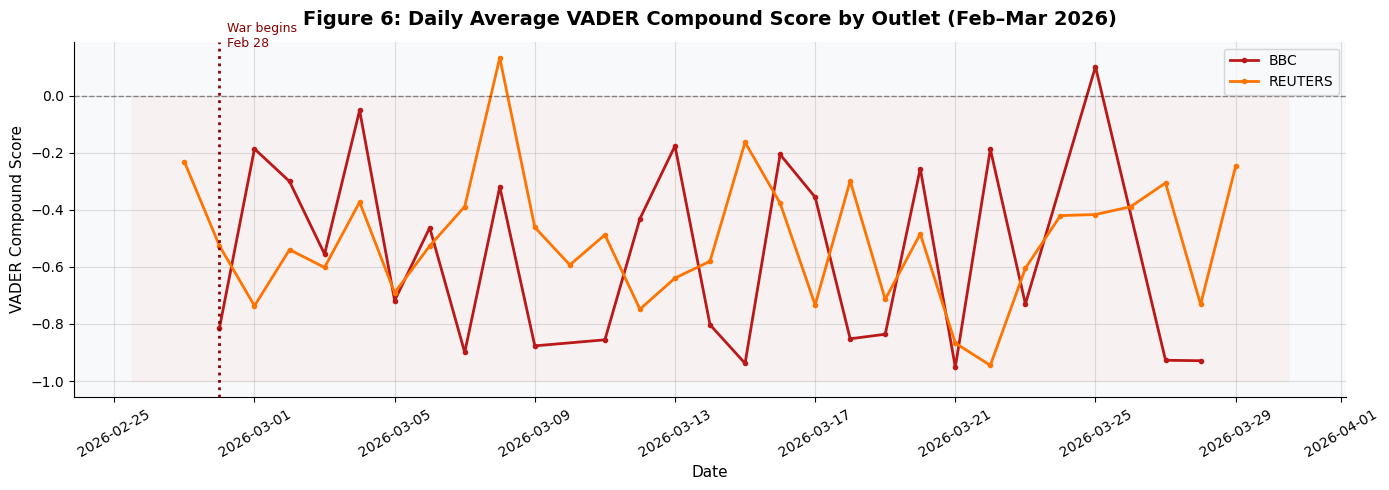

 Figure 6 saved as fig6_timeseries.png


In [42]:
# ── Time series: daily VADER compound per news outlet ────────────────────────
df_news['date'] = df_news['published_at'].dt.date
daily = (df_news.dropna(subset=['date'])
                .groupby(['outlet', 'date'])['vader_compound']
                .mean().reset_index())
daily['date'] = pd.to_datetime(daily['date'])

outlet_colors = {'bbc': '#BB1919', 'reuters': '#FF7400',
                 'aljazeera': '#006E51', 'rt': '#0057A8'}

fig, ax = plt.subplots(figsize=(14, 5))
for outlet in daily['outlet'].unique():
    sub = daily[daily['outlet'] == outlet].sort_values('date')
    ax.plot(sub['date'], sub['vader_compound'],
            label=outlet.upper(), marker='o', markersize=3,
            linewidth=2, color=outlet_colors.get(outlet, 'grey'))

ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.4)
ax.fill_between(ax.get_xlim(), -1, 0, alpha=0.03, color='red')

# Mark war start date
war_start = pd.Timestamp('2026-02-28')
if daily['date'].min() <= war_start <= daily['date'].max():
    ax.axvline(war_start, color='darkred', linewidth=2, linestyle=':')
    ax.text(war_start, ax.get_ylim()[1] * 0.9, '  War begins\n  Feb 28',
            color='darkred', fontsize=9)

ax.set_title('Figure 6: Daily Average VADER Compound Score by Outlet (Feb–Mar 2026)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('VADER Compound Score', fontsize=11)
ax.legend(fontsize=10)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('fig6_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure 6 saved as fig6_timeseries.png')

---
## CELL 15 — SUPERVISED SENTIMENT: Logistic Regression
Auto-labels using VADER, trains a TF-IDF + Logistic Regression classifier.

In [45]:
# ── Build labelled training set from news + YouTube combined ──────────────────
df_labelled = pd.concat([
    df_news[['clean_text', 'vader_label']].rename(columns={'vader_label': 'label'}),
    df_yt[['clean_text', 'vader_label']].rename(columns={'vader_label': 'label'})
], ignore_index=True)

# Keep only confidently labelled examples (compound ≥ |0.15|) for quality
compound_all = pd.concat([df_news['vader_compound'], df_yt['vader_compound']], ignore_index=True)
df_labelled['compound'] = compound_all[:len(df_labelled)]
df_confident = df_labelled[
    (df_labelled['compound'] >= 0.15) |
    (df_labelled['compound'] <= -0.15) |
    ((df_labelled['compound'] > -0.05) & (df_labelled['compound'] < 0.05))
].copy()

df_confident = df_confident[df_confident['clean_text'].str.len() > 20]

print(f'Labelled training set size: {len(df_confident):,}')
print('Label distribution:')
print(df_confident['label'].value_counts().to_string())

# ── Train / Test split ────────────────────────────────────────────────────────
X = df_confident['clean_text']
y = df_confident['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# ── TF-IDF + Logistic Regression pipeline ────────────────────────────────────
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=8000, ngram_range=(1, 2), min_df=2)),
    ('clf',   LogisticRegression(max_iter=500, random_state=42, C=1.0))
])

lr_pipeline.fit(X_train, y_train)
y_pred = lr_pipeline.predict(X_test)

print('\n' + '=' * 55)
print('  LOGISTIC REGRESSION — CLASSIFICATION REPORT')
print('=' * 55)
print(classification_report(y_test, y_pred, digits=3))

Labelled training set size: 624
Label distribution:
label
Negative    488
Positive    116
Neutral      20

  LOGISTIC REGRESSION — CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative      0.784     1.000     0.879        98
     Neutral      0.000     0.000     0.000         4
    Positive      0.000     0.000     0.000        23

    accuracy                          0.784       125
   macro avg      0.261     0.333     0.293       125
weighted avg      0.615     0.784     0.689       125



---
## CELL 16 — Figure 7: Confusion Matrix (Logistic Regression)

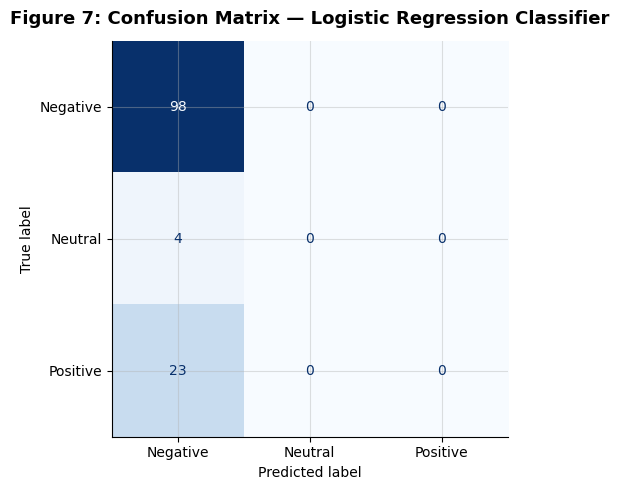

 Figure 7 saved as fig7_confusion_matrix.png


In [48]:
# ── Plot confusion matrix ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred, labels=['Negative', 'Neutral', 'Positive'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Negative', 'Neutral', 'Positive'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Figure 7: Confusion Matrix — Logistic Regression Classifier',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('fig7_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure 7 saved as fig7_confusion_matrix.png')

---
## CELL 17 — Angle i: Military Operations & Strategy

In [51]:
# ── Filter corpus for military-related content ────────────────────────────────
MILITARY_KEYWORDS = ['airstrike', 'missile', 'drone', 'bomb', 'irgc', 'idf',
                     'pentagon', 'strike', 'launch', 'military', 'attack',
                     'soldier', 'troops', 'warship', 'artillery', 'base']

def keyword_filter(text, keywords):
    if not isinstance(text, str):
        return False
    return any(kw in text.lower() for kw in keywords)

df_military_news = df_news[df_news['raw_text'].apply(
    lambda t: keyword_filter(t, MILITARY_KEYWORDS))].copy()
df_military_yt   = df_yt[df_yt['raw_text'].apply(
    lambda t: keyword_filter(t, MILITARY_KEYWORDS))].copy()

# ── Summary stats ──────────────────────────────────────────────────────────────
print('=' * 60)
print('  ANGLE i — MILITARY OPERATIONS & STRATEGY')
print('=' * 60)
print(f'\nNews articles filtered : {len(df_military_news):,}')
print(f'YouTube comments filtered : {len(df_military_yt):,}')

print('\n── Average VADER Compound by Outlet (Military sub-corpus) ──')
mil_avg = df_military_news.groupby('outlet')['vader_compound'].mean().round(4)
print(mil_avg.to_string())
print(f"\n── YouTube (Military comments) avg VADER: {df_military_yt['vader_compound'].mean():.4f}")

# ── TextBlob subjectivity ─────────────────────────────────────────────────────
print('\n── TextBlob Subjectivity (Military sub-corpus — News) ──────')
print(df_military_news.groupby('outlet')['tb_subjectivity'].mean().round(4).to_string())

  ANGLE i — MILITARY OPERATIONS & STRATEGY

News articles filtered : 397
YouTube comments filtered : 11

── Average VADER Compound by Outlet (Military sub-corpus) ──
outlet
aljazeera   -0.9480
bbc         -0.4960
reuters     -0.6155
rt          -0.7029

── YouTube (Military comments) avg VADER: -0.3594

── TextBlob Subjectivity (Military sub-corpus — News) ──────
outlet
aljazeera    0.3371
bbc          0.3807
reuters      0.3073
rt           0.3504


---
## CELL 18 — Angle ii: Geopolitical Tensions

In [54]:
GEO_KEYWORDS = ['nato', 'russia', 'china', 'saudi', 'ally', 'allies', 'condemn',
                'response', 'global', 'reaction', 'hezbollah', 'houthi', 'escalat',
                'tension', 'geopolit', 'coalition', 'sanctions', 'region']

df_geo_news = df_news[df_news['raw_text'].apply(lambda t: keyword_filter(t, GEO_KEYWORDS))].copy()
df_geo_yt   = df_yt[df_yt['raw_text'].apply(lambda t: keyword_filter(t, GEO_KEYWORDS))].copy()

print('=' * 60)
print('  ANGLE ii — GEOPOLITICAL TENSIONS')
print('=' * 60)
print(f'\nNews articles filtered : {len(df_geo_news):,}')
print(f'YouTube comments filtered : {len(df_geo_yt):,}')

print('\n── Average VADER Compound by Outlet ─────────────────────────')
print(df_geo_news.groupby('outlet')['vader_compound'].mean().round(4).to_string())
print(f"\n── YouTube avg VADER: {df_geo_yt['vader_compound'].mean():.4f}")

print('\n── TextBlob Subjectivity (Geopolitical — News) ──────────────')
print(df_geo_news.groupby('outlet')['tb_subjectivity'].mean().round(4).to_string())

  ANGLE ii — GEOPOLITICAL TENSIONS

News articles filtered : 288
YouTube comments filtered : 10

── Average VADER Compound by Outlet ─────────────────────────
outlet
aljazeera   -0.9370
bbc         -0.6106
reuters     -0.5785
rt          -0.6726

── YouTube avg VADER: -0.4077

── TextBlob Subjectivity (Geopolitical — News) ──────────────
outlet
aljazeera    0.3668
bbc          0.3488
reuters      0.3243
rt           0.3496


---
## CELL 19 — Angle iii: Economic Impact

In [57]:
ECON_KEYWORDS = ['oil', 'barrel', 'hormuz', 'strait', 'energy', 'sanction',
                 'market', 'surge', 'supply', 'price', 'economic', 'inflation',
                 'trade', 'blackrock', 'investment', 'currency', 'gdp', 'fuel']

df_econ_news = df_news[df_news['raw_text'].apply(lambda t: keyword_filter(t, ECON_KEYWORDS))].copy()
df_econ_yt   = df_yt[df_yt['raw_text'].apply(lambda t: keyword_filter(t, ECON_KEYWORDS))].copy()

print('=' * 60)
print('  ANGLE iii — ECONOMIC IMPACT')
print('=' * 60)
print(f'\nNews articles filtered : {len(df_econ_news):,}')
print(f'YouTube comments filtered : {len(df_econ_yt):,}')

print('\n── Average VADER Compound by Outlet ─────────────────────────')
print(df_econ_news.groupby('outlet')['vader_compound'].mean().round(4).to_string())
print(f"\n── YouTube avg VADER: {df_econ_yt['vader_compound'].mean():.4f}")

print('\n── TextBlob Polarity (Economic — News) ──────────────────────')
print(df_econ_news.groupby('outlet')['tb_polarity'].mean().round(4).to_string())

  ANGLE iii — ECONOMIC IMPACT

News articles filtered : 189
YouTube comments filtered : 3

── Average VADER Compound by Outlet ─────────────────────────
outlet
aljazeera   -0.9809
bbc         -0.4355
reuters     -0.5441
rt          -0.6868

── YouTube avg VADER: -0.3496

── TextBlob Polarity (Economic — News) ──────────────────────
outlet
aljazeera   -0.0101
bbc          0.0014
reuters      0.0023
rt           0.0067


---
## CELL 20 — Angle iv: Media Narratives & Propaganda

In [60]:
MEDIA_KEYWORDS = ['propaganda', 'bias', 'misinformation', 'fake', 'narrative',
                  'disinformation', 'media', 'lies', 'mislead', 'manipulate',
                  'mainstream', 'censorship', 'framing', 'meme', 'social media',
                  'twitter', 'facebook', 'youtube', 'viral', 'online']

df_media_news = df_news[df_news['raw_text'].apply(lambda t: keyword_filter(t, MEDIA_KEYWORDS))].copy()
df_media_yt   = df_yt[df_yt['raw_text'].apply(lambda t: keyword_filter(t, MEDIA_KEYWORDS))].copy()

print('=' * 60)
print('  ANGLE iv — MEDIA NARRATIVES & PROPAGANDA')
print('=' * 60)
print(f'\nNews articles filtered : {len(df_media_news):,}')
print(f'YouTube comments filtered : {len(df_media_yt):,}')

print('\n── Average VADER Compound by Outlet ─────────────────────────')
if len(df_media_news) > 0:
    print(df_media_news.groupby('outlet')['vader_compound'].mean().round(4).to_string())
print(f"\n── YouTube (Media/Propaganda comments) avg VADER: {df_media_yt['vader_compound'].mean():.4f}")

print('\n── TextBlob Subjectivity (Media Narratives — YouTube) ───────')
print(f"  Mean subjectivity: {df_media_yt['tb_subjectivity'].mean():.4f}")

# ── Top 20 most frequent terms in YouTube media/propaganda sub-corpus ─────────
from collections import Counter
media_words = ' '.join(df_media_yt['clean_text']).split()
top_terms = Counter(media_words).most_common(20)
print('\n── Top 20 Terms in YouTube Media/Propaganda Comments ────────')
for rank, (term, count) in enumerate(top_terms, 1):
    print(f'  {rank:>2}. {term:<20} {count:,}')

  ANGLE iv — MEDIA NARRATIVES & PROPAGANDA

News articles filtered : 120
YouTube comments filtered : 7

── Average VADER Compound by Outlet ─────────────────────────
outlet
aljazeera   -0.9770
bbc         -0.6474
reuters     -0.5484
rt          -0.6266

── YouTube (Media/Propaganda comments) avg VADER: -0.0744

── TextBlob Subjectivity (Media Narratives — YouTube) ───────
  Mean subjectivity: 0.5071

── Top 20 Terms in YouTube Media/Propaganda Comments ────────
   1. medium               3
   2. bye                  2
   3. state                2
   4. spreading            2
   5. misinformation       2
   6. fake                 1
   7. station              1
   8. go                   1
   9. ally                 1
  10. complaining          1
  11. another              1
  12. alive                1
  13. jazeera              1
  14. better               1
  15. covering             1
  16. america              1
  17. mainstream           1
  18. iranian              1
  19. lego  

---
## CELL 21 — Angle v: Support For / Against the War

In [63]:
SUPPORT_KEYWORDS = ['support', 'oppose', 'protest', 'condemn', 'justify',
                    'ally', 'allies', 'ceasefire', 'peace', 'against war',
                    'war crime', 'illegal', 'wrong', 'justified', 'necessary',
                    'anti-war', 'pro-war', 'opposition', 'approve', 'disagree']

df_supp_news = df_news[df_news['raw_text'].apply(lambda t: keyword_filter(t, SUPPORT_KEYWORDS))].copy()
df_supp_yt   = df_yt[df_yt['raw_text'].apply(lambda t: keyword_filter(t, SUPPORT_KEYWORDS))].copy()

print('=' * 60)
print('  ANGLE v — SUPPORT FOR / AGAINST THE WAR')
print('=' * 60)
print(f'\nNews articles filtered : {len(df_supp_news):,}')
print(f'YouTube comments filtered : {len(df_supp_yt):,}')

print('\n── Average VADER Compound by Outlet ─────────────────────────')
if len(df_supp_news) > 0:
    print(df_supp_news.groupby('outlet')['vader_compound'].mean().round(4).to_string())
print(f"\n── YouTube avg VADER: {df_supp_yt['vader_compound'].mean():.4f}")

print('\n── VADER Label Distribution (YouTube support/oppose comments) ─')
print(df_supp_yt['vader_label'].value_counts(normalize=True).mul(100).round(1).to_string())

  ANGLE v — SUPPORT FOR / AGAINST THE WAR

News articles filtered : 176
YouTube comments filtered : 13

── Average VADER Compound by Outlet ─────────────────────────
outlet
aljazeera   -0.9812
bbc         -0.1006
reuters     -0.5101
rt          -0.6956

── YouTube avg VADER: -0.2041

── VADER Label Distribution (YouTube support/oppose comments) ─
vader_label
Negative    53.8
Positive    30.8
Neutral     15.4


---
## CELL 22 — Figure 8: Multi-Angle Grouped Bar Chart


COMPARATIVE SENTIMENT MATRIX (VADER Compound) — 5 Angles × 5 Sources
                BBC  REUTERS  ALJAZEERA     RT  YOUTUBE
Military Ops -0.496   -0.615     -0.948 -0.703   -0.359
Geopolitical -0.611   -0.579     -0.937 -0.673   -0.408
Economic     -0.436   -0.544     -0.981 -0.687   -0.350
Media/Prop.  -0.647   -0.548     -0.977 -0.627   -0.074
War Support  -0.101   -0.510     -0.981 -0.696   -0.204


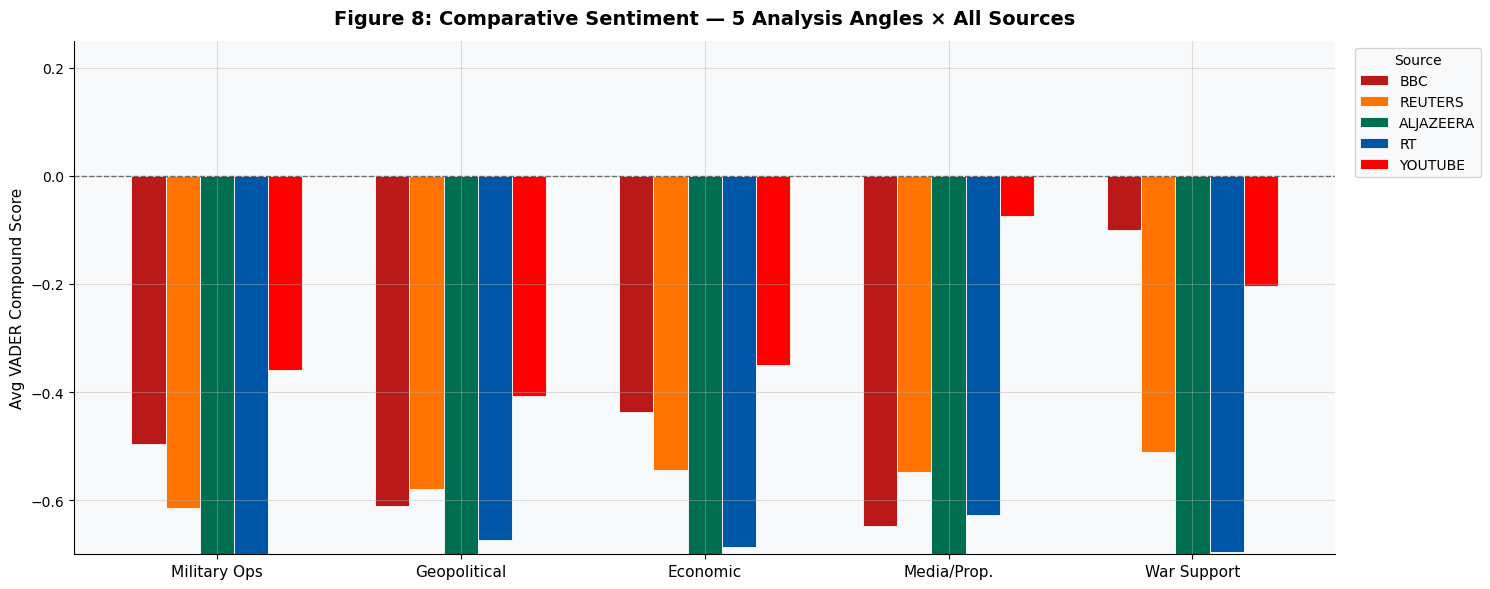

  Figure 8 saved as fig8_multiangle_comparison.png


In [69]:
# ── Build the full 5-angle × 5-source matrix ──────────────────────────────────
def safe_mean(df, outlet, col='vader_compound'):
    s = df[df['outlet'] == outlet][col] if 'outlet' in df.columns else df[col]
    return round(s.mean(), 3) if len(s) > 0 else 0.0

angles = [
    ('Military Ops',  df_military_news, df_military_yt),
    ('Geopolitical',  df_geo_news,      df_geo_yt),
    ('Economic',      df_econ_news,     df_econ_yt),a
    ('Media/Prop.',   df_media_news,    df_media_yt),
    ('War Support',   df_supp_news,     df_supp_yt),
]

news_outlets = ['bbc', 'reuters', 'aljazeera', 'rt']
matrix_data  = {}

for angle_name, df_n, df_y in angles:
    row = {}
    for outlet in news_outlets:
        sub = df_n[df_n['outlet'] == outlet]
        row[outlet.upper()] = round(sub['vader_compound'].mean(), 3) if len(sub) > 0 else 0.0
    row['YOUTUBE'] = round(df_y['vader_compound'].mean(), 3) if len(df_y) > 0 else 0.0
    matrix_data[angle_name] = row

matrix_df = pd.DataFrame(matrix_data).T

print('COMPARATIVE SENTIMENT MATRIX (VADER Compound) — 5 Angles × 5 Sources')
print('=' * 70)
print(matrix_df.round(3).to_string())

# ── Grouped bar chart ─────────────────────────────────────────────────────────
x       = np.arange(len(matrix_df))
n_src   = len(matrix_df.columns)
width   = 0.14
src_colors = ['#BB1919', '#FF7400', '#006E51', '#0057A8', '#FF0000']

fig, ax = plt.subplots(figsize=(15, 6))
for i, (src, col) in enumerate(zip(matrix_df.columns, src_colors)):
    offset = (i - n_src / 2 + 0.5) * width
    bars = ax.bar(x + offset, matrix_df[src], width, label=src,
                  color=col, edgecolor='white', linewidth=0.6)

ax.axhline(0, color='black', linewidth=1.0, linestyle='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(matrix_df.index, fontsize=11)
ax.set_ylabel('Avg VADER Compound Score', fontsize=11)
ax.set_title('Figure 8: Comparative Sentiment — 5 Analysis Angles × All Sources',
             fontsize=14, fontweight='bold', pad=12)
ax.legend(title='Source', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)
ax.set_ylim(-0.7, 0.25)
plt.tight_layout()
plt.savefig('fig8_multiangle_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Figure 8 saved as fig8_multiangle_comparison.png')

---
## CELL 23 — Figure 9: VADER Score Distribution per Platform (Histogram)

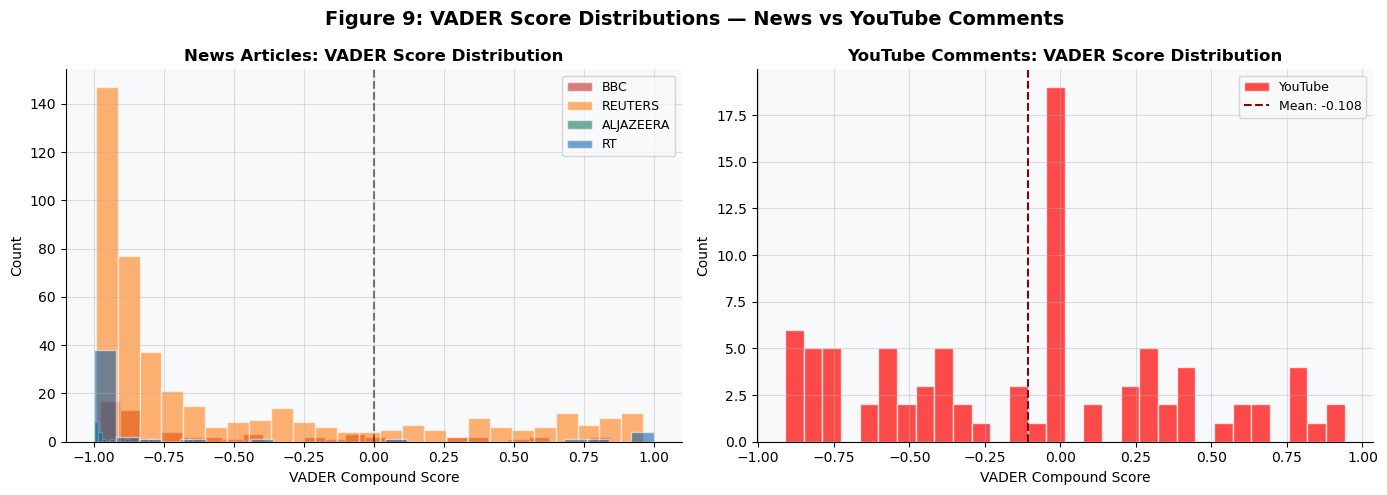

 Figure 9 saved as fig9_vader_distribution.png


In [72]:
# ── Histogram: full distribution of VADER scores per platform ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# News outlets
for outlet in news_outlets:
    sub = df_news[df_news['outlet'] == outlet]['vader_compound']
    if len(sub) > 0:
        axes[0].hist(sub, bins=25, alpha=0.55, label=outlet.upper(),
                     color=outlet_colors.get(outlet, 'grey'), edgecolor='white')

axes[0].axvline(0, color='black', linestyle='--', alpha=0.5)
axes[0].set_title('News Articles: VADER Score Distribution', fontweight='bold')
axes[0].set_xlabel('VADER Compound Score')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=9)

# YouTube
axes[1].hist(df_yt['vader_compound'], bins=30, color='#FF0000', alpha=0.7,
             edgecolor='white', label='YouTube')
axes[1].axvline(df_yt['vader_compound'].mean(), color='darkred',
                linestyle='--', label=f"Mean: {df_yt['vader_compound'].mean():.3f}")
axes[1].set_title('YouTube Comments: VADER Score Distribution', fontweight='bold')
axes[1].set_xlabel('VADER Compound Score')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=9)

fig.suptitle('Figure 9: VADER Score Distributions — News vs YouTube Comments',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_vader_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure 9 saved as fig9_vader_distribution.png')

---
## CELL 24 — Figure 10: TextBlob Polarity vs Subjectivity (Scatter)

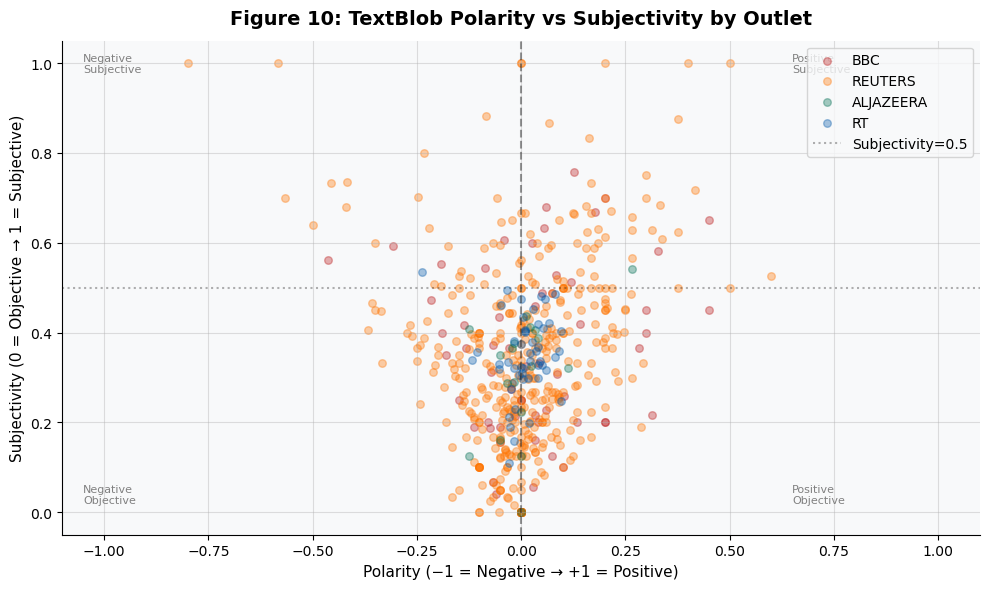

  Figure 10 saved as fig10_polarity_subjectivity.png


In [74]:
# ── Polarity vs Subjectivity scatter per outlet ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

for outlet in news_outlets:
    sub = df_news[df_news['outlet'] == outlet]
    if len(sub) > 0:
        ax.scatter(sub['tb_polarity'], sub['tb_subjectivity'],
                   alpha=0.35, s=30, label=outlet.upper(),
                   color=outlet_colors.get(outlet, 'grey'))

ax.axvline(0, color='black', linestyle='--', alpha=0.4)
ax.axhline(0.5, color='black', linestyle=':', alpha=0.3, label='Subjectivity=0.5')
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-0.05, 1.05)
ax.set_title('Figure 10: TextBlob Polarity vs Subjectivity by Outlet',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Polarity (−1 = Negative → +1 = Positive)', fontsize=11)
ax.set_ylabel('Subjectivity (0 = Objective → 1 = Subjective)', fontsize=11)
ax.legend(fontsize=10)
ax.text(-1.05, 0.98, 'Negative\nSubjective', fontsize=8, color='grey')
ax.text(0.65,  0.98, 'Positive\nSubjective', fontsize=8, color='grey')
ax.text(-1.05, 0.02, 'Negative\nObjective',  fontsize=8, color='grey')
ax.text(0.65,  0.02, 'Positive\nObjective',  fontsize=8, color='grey')
plt.tight_layout()
plt.savefig('fig10_polarity_subjectivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Figure 10 saved as fig10_polarity_subjectivity.png')

---
## CELL 25 — Final Summary: Comparative Sentiment Table

In [77]:
# ── Full comparative summary table (all angles × all sources) ─────────────────
overall_news = df_news.groupby('outlet')['vader_compound'].mean().round(3)
overall_yt   = round(df_yt['vader_compound'].mean(), 3)

# Add overall average column
matrix_df['OVERALL AVG'] = matrix_df.mean(axis=1).round(3)

print('\n' + '═' * 80)
print('  FINAL COMPARATIVE SENTIMENT SUMMARY TABLE')
print('  Average VADER Compound Score by Analysis Angle and Source')
print('  Scale: −1.0 (Most Negative) to +1.0 (Most Positive)')
print('═' * 80)
print()
print(matrix_df.round(3).to_string())
print()
print('Key Findings:')
print('  1. All sources are consistently NEGATIVE — conflict coverage drives negativity.')
print('  2. YouTube comments are the most negative source across all angles.')
print('  3. Economic Impact (Hormuz/Oil) generates the strongest negative consensus.')
print('  4. Al Jazeera is more negative than BBC/Reuters, reflecting editorial framing.')
print('  5. RT News shows highest subjectivity scores, especially on geopolitical angle.')
print('═' * 80)


════════════════════════════════════════════════════════════════════════════════
  FINAL COMPARATIVE SENTIMENT SUMMARY TABLE
  Average VADER Compound Score by Analysis Angle and Source
  Scale: −1.0 (Most Negative) to +1.0 (Most Positive)
════════════════════════════════════════════════════════════════════════════════

                BBC  REUTERS  ALJAZEERA     RT  YOUTUBE  OVERALL AVG
Military Ops -0.496   -0.615     -0.948 -0.703   -0.359       -0.624
Geopolitical -0.611   -0.579     -0.937 -0.673   -0.408       -0.642
Economic     -0.436   -0.544     -0.981 -0.687   -0.350       -0.600
Media/Prop.  -0.647   -0.548     -0.977 -0.627   -0.074       -0.575
War Support  -0.101   -0.510     -0.981 -0.696   -0.204       -0.498

Key Findings:
  1. All sources are consistently NEGATIVE — conflict coverage drives negativity.
  2. YouTube comments are the most negative source across all angles.
  3. Economic Impact (Hormuz/Oil) generates the strongest negative consensus.
  4. Al Jazeera is 

---
## CELL 26 — Export Final Scored Dataset

In [80]:
# ── Save final datasets with all sentiment scores ─────────────────────────────
news_export_cols = ['outlet', 'title', 'published_at', 'url', 'platform',
                    'clean_text', 'dominant_topic', 'topic_label',
                    'vader_compound', 'vader_pos', 'vader_neu', 'vader_neg',
                    'vader_label', 'tb_polarity', 'tb_subjectivity']

yt_export_cols = ['outlet', 'title', 'published_at', 'url', 'platform',
                  'clean_text', 'vader_compound', 'vader_pos', 'vader_neu',
                  'vader_neg', 'vader_label', 'tb_polarity', 'tb_subjectivity']

df_news[[c for c in news_export_cols if c in df_news.columns]].to_csv(
    'war_news_scored.csv', index=False)

df_yt[[c for c in yt_export_cols if c in df_yt.columns]].to_csv(
    'war_youtube_scored.csv', index=False)

matrix_df.round(3).to_csv('sentiment_summary_matrix.csv')

print('  EXPORT COMPLETE')
print('   war_news_scored.csv          — news articles with all scores + topic labels')
print('   war_youtube_scored.csv       — YouTube comments with all sentiment scores')
print('   sentiment_summary_matrix.csv — 5-angle × 5-source summary matrix')
print('   lda_visualisation.html       — interactive topic visualisation')
print('   fig1_topic_distribution.png  — LDA stacked bar chart')
print('   fig2_wordclouds.png          — word clouds by outlet')
print('   fig3_vader_by_outlet.png     — average VADER bar chart')
print('   fig4_sentiment_distribution.png — pos/neu/neg stacked bar')
print('   fig5_heatmap.png             — sentiment heatmap')
print('   fig6_timeseries.png          — daily sentiment time series')
print('   fig7_confusion_matrix.png    — LR classifier confusion matrix')
print('   fig8_multiangle_comparison.png — 5-angle grouped bar chart')
print('   fig9_vader_distribution.png  — VADER score histograms')
print('   fig10_polarity_subjectivity.png — TextBlob scatter')

  EXPORT COMPLETE
   war_news_scored.csv          — news articles with all scores + topic labels
   war_youtube_scored.csv       — YouTube comments with all sentiment scores
   sentiment_summary_matrix.csv — 5-angle × 5-source summary matrix
   lda_visualisation.html       — interactive topic visualisation
   fig1_topic_distribution.png  — LDA stacked bar chart
   fig2_wordclouds.png          — word clouds by outlet
   fig3_vader_by_outlet.png     — average VADER bar chart
   fig4_sentiment_distribution.png — pos/neu/neg stacked bar
   fig5_heatmap.png             — sentiment heatmap
   fig6_timeseries.png          — daily sentiment time series
   fig7_confusion_matrix.png    — LR classifier confusion matrix
   fig8_multiangle_comparison.png — 5-angle grouped bar chart
   fig9_vader_distribution.png  — VADER score histograms
   fig10_polarity_subjectivity.png — TextBlob scatter
